<a href="https://www.kaggle.com/code/rainasirsultan/kalima?scriptVersionId=355010931" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os

os.environ["CUDA_VISIBLE_DEVICES"] = "0"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

!pip install -q "datasets>=3.0,<4.0" jiwer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.6/193.6 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 146.7/146.7 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 48.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.48.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
pathos 0.3.5 requires dill>=0.4.1, but you have dill 0.3.8 which is incompatible.
pathos 0.3.5 requires multiprocess>=0.70.19, but you have multiprocess 0.70.16 which is incompatible.
s3fs 2025.12.0 requires fsspec==2025.12.0, but you have fsspec 2025.3.0 which is incompatible.
tpot 1.1.0 requires dill>=0.3.9, but you have dill 0

In [2]:
import os
import re
import json
import glob
from dataclasses import dataclass

import torch
import jiwer
import pandas as pd
from datasets import load_dataset, Audio
from huggingface_hub import HfApi, login, create_repo, snapshot_download
from kaggle_secrets import UserSecretsClient
from transformers import (
    WhisperProcessor,
    WhisperForConditionalGeneration,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    TrainerCallback,
)
from transformers.trainer_utils import get_last_checkpoint

DATASET_ID = "CUAIStudents/Ar-ASR"
AUDIO_COL = "audio"
TEXT_COL = "text"
BASE_MODEL = "openai/whisper-tiny"
HUB_REPO = "Nasir6/whisper-tiny-ar-asr"

WORK = "/kaggle/working/ar_asr"
CKPT_DIR = f"{WORK}/checkpoints"
HUB_CKPT = f"{WORK}/last-checkpoint"
FINAL_DIR = f"{WORK}/final_model"

TRAIN_WITH_TASHKEEL = False
MAX_STEPS = 4000
SAVE_STEPS = 500
TRAIN_BS = 16
GRAD_ACCUM = 2
LR = 5e-5
EVAL_BS = 32
EVAL_CHUNK = 100
MAX_LABEL_LEN = 448

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("GPUs visible:", torch.cuda.device_count())

login(UserSecretsClient().get_secret("HF_TOKEN"))
api = HfApi()
create_repo(HUB_REPO, private=True, exist_ok=True)
os.makedirs(WORK, exist_ok=True)
snapshot_download(repo_id=HUB_REPO, local_dir=WORK)

print(sorted(os.listdir(WORK)))

GPUs visible: 1


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 98 files:   0%|          | 0/98 [00:00<?, ?it/s]

['.cache', '.gitattributes', 'after', 'after_v2', 'after_v2_beam5', 'before', 'comparison.csv', 'final_model', 'last-checkpoint', 'summary.csv', 'v2_best', 'v2_checkpoint', 'v2_final_model', 'v3_best', 'v3_checkpoint']


In [3]:
DIACRITICS = re.compile(r"[\u0610-\u061A\u064B-\u065F\u0670\u06D6-\u06ED\u0640]")


def strip_tashkeel(text):
    return DIACRITICS.sub("", text)


def normalize_ar(text):
    text = strip_tashkeel(str(text))
    text = re.sub(r"[إأآٱا]", "ا", text)
    text = text.replace("ى", "ي").replace("ة", "ه")
    text = re.sub(r"[^\w\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()


def prepare_target(text):
    return text if TRAIN_WITH_TASHKEEL else strip_tashkeel(text)


def push_file(path):
    api.upload_file(
        path_or_fileobj=path,
        path_in_repo=os.path.relpath(path, WORK),
        repo_id=HUB_REPO,
    )


def push_folder(path, path_in_repo):
    api.upload_folder(folder_path=path, path_in_repo=path_in_repo, repo_id=HUB_REPO)


def transcribe_chunk(model, start, end):
    rows = []
    for i in range(start, end, EVAL_BS):
        j = min(i + EVAL_BS, end)
        batch = test_ds[i:j]
        features = processor.feature_extractor(
            [a["array"] for a in batch[AUDIO_COL]],
            sampling_rate=16000,
            return_tensors="pt",
        ).input_features.to(DEVICE, torch.float16)
        with torch.no_grad():
            ids = model.generate(features, language="ar", task="transcribe", max_new_tokens=225)
        preds = processor.batch_decode(ids, skip_special_tokens=True)
        for k, (ref, pred) in enumerate(zip(batch[TEXT_COL], preds)):
            rows.append({"idx": i + k, "reference": ref, "prediction": pred.strip()})
    return rows


def compute_metrics(df):
    df["reference_norm"] = df["reference"].map(normalize_ar)
    df["prediction_norm"] = df["prediction"].map(normalize_ar)
    valid = df[df["reference_norm"].str.len() > 0]
    refs = valid["reference_norm"].tolist()
    hyps = valid["prediction_norm"].tolist()
    return {"samples": len(valid), "wer": jiwer.wer(refs, hyps), "cer": jiwer.cer(refs, hyps)}


def run_eval(model, name):
    out_dir = f"{WORK}/{name}"
    parts_dir = f"{out_dir}/parts"
    metrics_path = f"{out_dir}/metrics.json"

    if os.path.exists(metrics_path):
        with open(metrics_path) as f:
            return json.load(f)

    os.makedirs(parts_dir, exist_ok=True)
    model.to(DEVICE).half().eval()
    total = len(test_ds)

    for start in range(0, total, EVAL_CHUNK):
        part_path = f"{parts_dir}/part_{start:05d}.csv"
        if os.path.exists(part_path):
            continue
        end = min(start + EVAL_CHUNK, total)
        pd.DataFrame(transcribe_chunk(model, start, end)).to_csv(part_path, index=False)
        push_file(part_path)
        print(f"{name}: {end}/{total}")

    parts = sorted(glob.glob(f"{parts_dir}/*.csv"))
    df = pd.concat([pd.read_csv(p) for p in parts]).sort_values("idx").fillna("")
    metrics = {"model": name, **compute_metrics(df)}

    df.to_csv(f"{out_dir}/transcripts.csv", index=False, encoding="utf-8-sig")
    with open(metrics_path, "w") as f:
        json.dump(metrics, f, indent=2)
    push_file(f"{out_dir}/transcripts.csv")
    push_file(metrics_path)
    return metrics

In [4]:
processor = WhisperProcessor.from_pretrained(BASE_MODEL, language="arabic", task="transcribe")

ds = load_dataset(DATASET_ID)
ds = ds.cast_column(AUDIO_COL, Audio(sampling_rate=16000))
test_ds = ds["test"]


def label_fits(texts):
    cleaned = [prepare_target(t or "") for t in texts]
    ids = processor.tokenizer(cleaned).input_ids
    return [len(c.strip()) > 0 and len(x) <= MAX_LABEL_LEN for c, x in zip(cleaned, ids)]


train_ds = ds["train"].filter(label_fits, input_columns=[TEXT_COL], batched=True, num_proc=2)
print(train_ds)
print(test_ds)

preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.98k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/283k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/836k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.48M [00:00<?, ?B/s]

...

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/33607 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter (num_proc=2):   0%|          | 0/33607 [00:00<?, ? examples/s]

Dataset({
    features: ['audio', 'text'],
    num_rows: 33607
})
Dataset({
    features: ['audio', 'text'],
    num_rows: 1000
})


In [5]:
base_model = WhisperForConditionalGeneration.from_pretrained(BASE_MODEL)
before = run_eval(base_model, "before")
print(before)

del base_model
torch.cuda.empty_cache()

model.safetensors: reconstructing file:   0%|          |  0.00B /  151MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/3.75k [00:00<?, ?B/s]

{'model': 'before', 'samples': 1000, 'wer': 0.7007494646680942, 'cer': 0.29507544881607983}


In [6]:
@dataclass
class WhisperCollator:
    processor: WhisperProcessor
    decoder_start_token_id: int

    def __call__(self, batch):
        audios = [b[AUDIO_COL]["array"] for b in batch]
        features = self.processor.feature_extractor(
            audios, sampling_rate=16000, return_tensors="pt"
        ).input_features
        texts = [prepare_target(b[TEXT_COL]) for b in batch]
        tokens = self.processor.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=MAX_LABEL_LEN,
            return_tensors="pt",
        )
        labels = tokens.input_ids.masked_fill(tokens.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.decoder_start_token_id).all():
            labels = labels[:, 1:]
        return {"input_features": features, "labels": labels}


class HubCheckpointSync(TrainerCallback):
    def on_save(self, args, state, control, **kwargs):
        ckpt = os.path.join(args.output_dir, f"checkpoint-{state.global_step}")
        push_folder(ckpt, "last-checkpoint")
        print(f"checkpoint {state.global_step} pushed to hub")


if api.file_exists(HUB_REPO, "final_model/model.safetensors"):
    print("training already completed")
else:
    model = WhisperForConditionalGeneration.from_pretrained(BASE_MODEL)
    model.generation_config.language = "arabic"
    model.generation_config.task = "transcribe"
    model.generation_config.forced_decoder_ids = None

    args = Seq2SeqTrainingArguments(
        output_dir=CKPT_DIR,
        per_device_train_batch_size=TRAIN_BS,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=LR,
        warmup_steps=500,
        max_steps=MAX_STEPS,
        fp16=torch.cuda.is_available(),
        save_steps=SAVE_STEPS,
        save_total_limit=2,
        logging_steps=50,
        eval_strategy="no",
        report_to="none",
        dataloader_num_workers=2,
        remove_unused_columns=False,
        ignore_data_skip=True,
        label_names=["labels"],
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=train_ds,
        data_collator=WhisperCollator(processor, model.config.decoder_start_token_id),
        callbacks=[HubCheckpointSync()],
    )

    local_ckpt = get_last_checkpoint(CKPT_DIR) if os.path.isdir(CKPT_DIR) else None
    hub_ckpt = HUB_CKPT if os.path.exists(f"{HUB_CKPT}/trainer_state.json") else None
    resume_from = local_ckpt or hub_ckpt
    print("resume from:", resume_from)

    trainer.train(resume_from_checkpoint=resume_from)
    trainer.save_model(FINAL_DIR)
    processor.save_pretrained(FINAL_DIR)
    push_folder(FINAL_DIR, "final_model")

    del trainer, model
    torch.cuda.empty_cache()

training already completed


In [7]:
ft_model = WhisperForConditionalGeneration.from_pretrained(FINAL_DIR)
after = run_eval(ft_model, "after")
print(after)

del ft_model
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

{'model': 'after', 'samples': 1000, 'wer': 0.14732334047109208, 'cer': 0.047575498518857236}


In [8]:
with open(f"{WORK}/before/metrics.json") as f:
    before = json.load(f)
with open(f"{WORK}/after/metrics.json") as f:
    after = json.load(f)

summary = pd.DataFrame({
    "metric": ["WER", "CER"],
    "before": [before["wer"], before["cer"]],
    "after": [after["wer"], after["cer"]],
})
summary["improvement_%"] = (summary["before"] - summary["after"]) / summary["before"] * 100
print(summary.round(4).to_string(index=False))

before_df = pd.read_csv(f"{WORK}/before/transcripts.csv")
after_df = pd.read_csv(f"{WORK}/after/transcripts.csv")

side_by_side = (
    before_df[["idx", "reference", "prediction"]]
    .rename(columns={"prediction": "before"})
    .merge(after_df[["idx", "prediction"]].rename(columns={"prediction": "after"}), on="idx")
)

side_by_side.to_csv(f"{WORK}/comparison.csv", index=False, encoding="utf-8-sig")
summary.to_csv(f"{WORK}/summary.csv", index=False)
push_file(f"{WORK}/comparison.csv")
push_file(f"{WORK}/summary.csv")

side_by_side.head(10)


metric  before  after  improvement_%
   WER  0.7007 0.1473        78.9763
   CER  0.2951 0.0476        83.8768


No files have been modified since last commit. Skipping to prevent empty commit.
No files have been modified since last commit. Skipping to prevent empty commit.


,idx,reference,before,after
0,0,رَبَّنَا أَخْرِجْنَا مِنْهَا فَإِنْ عُدْنَا فَ...,أخذنا منها في النظل المنظل,والبنى أخرجنا منها فإن عدنا فإن ظلمون
1,1,حَمْدِينُ صَبَّاحِيِّ مُؤَسِّسِ التَّيَّارِ ال...,حمدين سباحي مؤسس التيار شعبي المصري ومحمد البر...,حمدين صباحيم أسس التيار الشعبي المصري ومحمد ال...
2,2,وَلَا زِيَادَةِ تَطَوُّعٍ عَلَى رَاتِبَتِهَا,وليسيه تجدتا وينعنا راجبة جهة,ولا زيدت تطول على راتبتها
3,3,الْأَعْدَادُ الْحَقِيقِيَّةُ تُعَمَّمُ عَلَى ا...,الأعادة الحقيقية توعمم على الأعادة العقدية,الأعداد الحقيقية تعمى معل الأعداد العقدية
4,4,وَقِفُوهُمْ إِنَّهُمْ مَسْئُولُون,واتقفوا هم إنا همس أولون,وقفوهم إنه مسئولون
5,5,حَيْثُ يَمْتَدُّ مِنْ حَدِيقَةِ الْحَيَوَانَات...,حيث ينتد من حديقة الحياوانات إلى من طقة شرلوة ...,حيث ينتد من حديقة الحيوانات إلى منطقة شارلو تن...
6,6,سَوَاءٌ مَا اطَّلَعَ عَلَيْهِ النَّاسُ أَوْ مَ...,سبيعون مقلالة الهنس ومخفيان ايوني,سواء ما إطلا عليه الناس أو ما أخفي عن عيوني
7,7,وَغَنَاءٌ وغناء لَوْلَا أَنَّهُ فَنَاءٌ وَجَسِ...,وغناء وغناء لولاء النهوفنا وجسي من لولاء النهو...,وغناء وغناء لولا أنه فنا وجسيم لولا أنه ذميم
8,8,وَأَنَّ هَذَا لَا يُشَارِكُ الجَيْشَ فِيمَا أَ...,وأنها ذلك يشارك الجيش في معصور بوضة قبل أن يلت...,وأن هذا لا يشارك الجيش فيما أصابوه قبل أن يلتح...
9,9,أَلَسْتُمْ تَذْهَبُونَ فَرْغًا وَتَرْجِعُونَ م...,الاسطم تذبون فرغن وطر جعون مشاريل قالو,ألستم تذهبون فرغا وترجعون مشاغيل قالوا


In [9]:
files = api.list_repo_files(HUB_REPO)

print(f"Total files in {HUB_REPO}: {len(files)}\n")
for f in sorted(files):
    print(f)

required = [
    "final_model/model.safetensors",
    "final_model/config.json",
    "final_model/generation_config.json",
    "final_model/preprocessor_config.json",
    "final_model/tokenizer_config.json",
]

print("\nRequired files check:")
for r in required:
    print("OK     " if r in files else "MISSING", r)

hub_model = WhisperForConditionalGeneration.from_pretrained(HUB_REPO, subfolder="final_model")
hub_processor = WhisperProcessor.from_pretrained(HUB_REPO, subfolder="final_model")
hub_model.to(DEVICE).half().eval()

sample = test_ds[0]
features = hub_processor.feature_extractor(
    sample[AUDIO_COL]["array"], sampling_rate=16000, return_tensors="pt"
).input_features.to(DEVICE, torch.float16)

with torch.no_grad():
    ids = hub_model.generate(features, language="ar", task="transcribe", max_new_tokens=225)

print("\nReference :", sample[TEXT_COL])
print("Prediction:", hub_processor.batch_decode(ids, skip_special_tokens=True)[0])

Total files in Nasir6/whisper-tiny-ar-asr: 98

.gitattributes
after/metrics.json
after/parts/part_00000.csv
after/parts/part_00100.csv
after/parts/part_00200.csv
after/parts/part_00300.csv
after/parts/part_00400.csv
after/parts/part_00500.csv
after/parts/part_00600.csv
after/parts/part_00700.csv
after/parts/part_00800.csv
after/parts/part_00900.csv
after/transcripts.csv
after_v2/error_analysis.csv
after_v2/metrics.json
after_v2/parts/part_00000.csv
after_v2/parts/part_00100.csv
after_v2/parts/part_00200.csv
after_v2/parts/part_00300.csv
after_v2/parts/part_00400.csv
after_v2/parts/part_00500.csv
after_v2/parts/part_00600.csv
after_v2/parts/part_00700.csv
after_v2/parts/part_00800.csv
after_v2/parts/part_00900.csv
after_v2/transcripts.csv
after_v2_beam5/metrics.json
after_v2_beam5/parts/part_00000.csv
after_v2_beam5/parts/part_00100.csv
after_v2_beam5/parts/part_00200.csv
after_v2_beam5/parts/part_00300.csv
after_v2_beam5/parts/part_00400.csv
after_v2_beam5/parts/part_00500.csv
after_v2

config.json:   0%|          | 0.00/2.21k [00:00<?, ?B/s]

final_model/model.safetensors: reconstructing file:   0%|          |  0.00B /  151MB            

final_model/model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

...

processor_config.json:   0%|          | 0.00/409 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.12k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.93M [00:00<?, ?B/s]

[transformers] Passing `generation_config` together with generation-related arguments=({'begin_suppress_tokens', 'suppress_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=225) and `max_length`(=448) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer WhisperTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.



Reference : رَبَّنَا أَخْرِجْنَا مِنْهَا فَإِنْ عُدْنَا فَإِنَّا ظَالِمُون
Prediction: والبنى أخرجنا منها فإن عدنا فإن ظلمون


In [10]:
V2_LR = 1e-5
V2_STEPS = 3000
V2_WARMUP = 200
V2_SAVE_STEPS = 500
VAL_SIZE = 500
EVAL_BEAMS = 1

V2_CKPT_DIR = f"{WORK}/v2_checkpoints"
V2_HUB_CKPT = f"{WORK}/v2_checkpoint"
V2_BEST_DIR = f"{WORK}/v2_best"
V2_FINAL_DIR = f"{WORK}/v2_final_model"

split = train_ds.train_test_split(test_size=VAL_SIZE, seed=42)
v2_train_ds = split["train"]
val_ds = split["test"]
print("v2 train:", len(v2_train_ds), "| validation:", len(val_ds), "| test:", len(test_ds))


def push_folder(path, path_in_repo, allow_patterns=None):
    api.upload_folder(
        folder_path=path,
        path_in_repo=path_in_repo,
        repo_id=HUB_REPO,
        allow_patterns=allow_patterns,
    )


def transcribe_chunk(model, start, end):
    rows = []
    for i in range(start, end, EVAL_BS):
        j = min(i + EVAL_BS, end)
        batch = test_ds[i:j]
        features = processor.feature_extractor(
            [a["array"] for a in batch[AUDIO_COL]],
            sampling_rate=16000,
            return_tensors="pt",
        ).input_features.to(DEVICE, torch.float16)
        with torch.no_grad():
            ids = model.generate(
                features,
                language="ar",
                task="transcribe",
                max_new_tokens=225,
                num_beams=EVAL_BEAMS,
            )
        preds = processor.batch_decode(ids, skip_special_tokens=True)
        for k, (ref, pred) in enumerate(zip(batch[TEXT_COL], preds)):
            rows.append({"idx": i + k, "reference": ref, "prediction": pred.strip()})
    return rows


@dataclass
class WhisperCollator:
    processor: WhisperProcessor
    decoder_start_token_id: int

    def __call__(self, batch):
        audios = [b[AUDIO_COL]["array"] for b in batch]
        features = self.processor.feature_extractor(
            audios, sampling_rate=16000, return_tensors="pt"
        ).input_features
        texts = [prepare_target(b[TEXT_COL]) for b in batch]
        tokens = self.processor.tokenizer(
            texts,
            padding=True,
            truncation=True,
            max_length=MAX_LABEL_LEN,
            return_tensors="pt",
        )
        labels = tokens.input_ids.masked_fill(tokens.attention_mask.ne(1), -100)
        if (labels[:, 0] == self.decoder_start_token_id).all():
            labels = labels[:, 1:]
        return {"input_features": features, "labels": labels}


def trainer_metrics(pred):
    pad_id = processor.tokenizer.pad_token_id
    pred_ids = pred.predictions
    label_ids = pred.label_ids
    pred_ids[pred_ids == -100] = pad_id
    label_ids[label_ids == -100] = pad_id
    preds = [normalize_ar(p) for p in processor.batch_decode(pred_ids, skip_special_tokens=True)]
    refs = [normalize_ar(r) for r in processor.batch_decode(label_ids, skip_special_tokens=True)]
    pairs = [(r, p) for r, p in zip(refs, preds) if r]
    refs_n = [r for r, _ in pairs]
    preds_n = [p for _, p in pairs]
    return {"wer": jiwer.wer(refs_n, preds_n), "cer": jiwer.cer(refs_n, preds_n)}


class V2HubSync(TrainerCallback):
    def on_save(self, args, state, control, **kwargs):
        ckpt = os.path.join(args.output_dir, f"checkpoint-{state.global_step}")
        push_folder(ckpt, "v2_checkpoint")
        print(f"v2 checkpoint {state.global_step} pushed to hub")
        if state.best_model_checkpoint == ckpt:
            push_folder(
                ckpt,
                "v2_best",
                allow_patterns=["model.safetensors", "config.json", "generation_config.json"],
            )
            print(f"new best at step {state.global_step}: val WER {state.best_metric:.4f}")

v2 train: 33107 | validation: 500 | test: 1000


In [11]:
if api.file_exists(HUB_REPO, "v2_final_model/model.safetensors"):
    print("v2 training already completed")
else:
    model = WhisperForConditionalGeneration.from_pretrained(FINAL_DIR)
    model.generation_config.language = "arabic"
    model.generation_config.task = "transcribe"
    model.generation_config.forced_decoder_ids = None

    args = Seq2SeqTrainingArguments(
        output_dir=V2_CKPT_DIR,
        per_device_train_batch_size=TRAIN_BS,
        per_device_eval_batch_size=EVAL_BS,
        gradient_accumulation_steps=GRAD_ACCUM,
        learning_rate=V2_LR,
        warmup_steps=V2_WARMUP,
        max_steps=V2_STEPS,
        fp16=torch.cuda.is_available(),
        eval_strategy="steps",
        eval_steps=V2_SAVE_STEPS,
        save_steps=V2_SAVE_STEPS,
        save_total_limit=2,
        metric_for_best_model="wer",
        greater_is_better=False,
        predict_with_generate=True,
        generation_max_length=225,
        logging_steps=50,
        report_to="none",
        dataloader_num_workers=2,
        remove_unused_columns=False,
        ignore_data_skip=True,
        label_names=["labels"],
    )

    trainer = Seq2SeqTrainer(
        model=model,
        args=args,
        train_dataset=v2_train_ds,
        eval_dataset=val_ds,
        data_collator=WhisperCollator(processor, model.config.decoder_start_token_id),
        compute_metrics=trainer_metrics,
        callbacks=[V2HubSync()],
    )

    local_ckpt = get_last_checkpoint(V2_CKPT_DIR) if os.path.isdir(V2_CKPT_DIR) else None
    hub_ckpt = V2_HUB_CKPT if os.path.exists(f"{V2_HUB_CKPT}/trainer_state.json") else None
    resume_from = local_ckpt or hub_ckpt
    print("resume from:", resume_from)

    trainer.train(resume_from_checkpoint=resume_from)

    snapshot_download(repo_id=HUB_REPO, local_dir=WORK, allow_patterns=["v2_best/*"])
    best_model = WhisperForConditionalGeneration.from_pretrained(V2_BEST_DIR)
    best_model.save_pretrained(V2_FINAL_DIR)
    processor.save_pretrained(V2_FINAL_DIR)
    push_folder(V2_FINAL_DIR, "v2_final_model")

    del trainer, model, best_model
    torch.cuda.empty_cache()

v2 training already completed


In [12]:
v2_model = WhisperForConditionalGeneration.from_pretrained(V2_FINAL_DIR)

EVAL_BEAMS = 1
EVAL_BS = 32
v2_greedy = run_eval(v2_model, "after_v2")
print(v2_greedy)

EVAL_BEAMS = 5
EVAL_BS = 16
v2_beam = run_eval(v2_model, "after_v2_beam5")
print(v2_beam)

del v2_model
torch.cuda.empty_cache()

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

{'model': 'after_v2', 'samples': 1000, 'wer': 0.14314775160599572, 'cer': 0.04180997634147796}
{'model': 'after_v2_beam5', 'samples': 1000, 'wer': 0.15481798715203426, 'cer': 0.05449412513171236}


         model    wer    cer  word_acc_%  char_acc_%  gap_to_target_%
        before 0.7007 0.2951     29.9251     70.4925          68.0749
         after 0.1473 0.0476     85.2677     95.2425          12.7323
      after_v2 0.1431 0.0418     85.6852     95.8190          12.3148
after_v2_beam5 0.1548 0.0545     84.5182     94.5506          13.4818


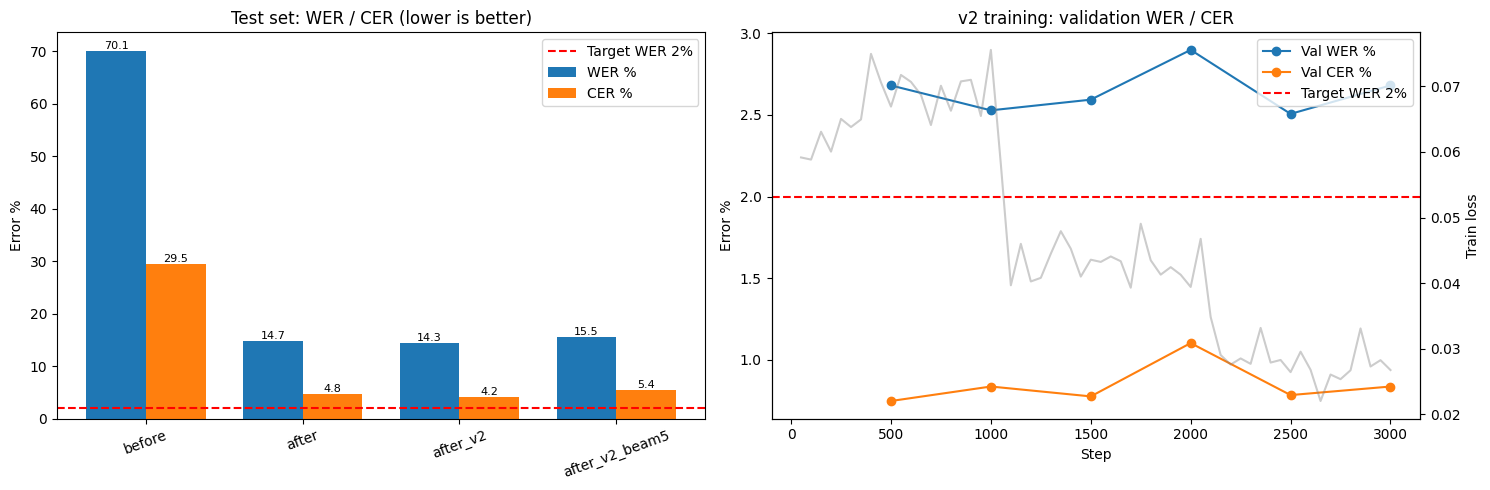

In [13]:
import matplotlib.pyplot as plt

TARGET_WER = 0.02
names = ["before", "after", "after_beam5", "after_v2", "after_v2_beam5"]

rows = []
for name in names:
    path = f"{WORK}/{name}/metrics.json"
    if os.path.exists(path):
        with open(path) as f:
            m = json.load(f)
        rows.append({"model": name, "wer": m["wer"], "cer": m["cer"]})

metrics_df = pd.DataFrame(rows)
metrics_df["word_acc_%"] = (1 - metrics_df["wer"]) * 100
metrics_df["char_acc_%"] = (1 - metrics_df["cer"]) * 100
metrics_df["gap_to_target_%"] = (metrics_df["wer"] - TARGET_WER) * 100
print(metrics_df.round(4).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

x = range(len(metrics_df))
width = 0.38
axes[0].bar([i - width / 2 for i in x], metrics_df["wer"] * 100, width, label="WER %")
axes[0].bar([i + width / 2 for i in x], metrics_df["cer"] * 100, width, label="CER %")
axes[0].axhline(TARGET_WER * 100, color="red", linestyle="--", label="Target WER 2%")
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(metrics_df["model"], rotation=20)
axes[0].set_ylabel("Error %")
axes[0].set_title("Test set: WER / CER (lower is better)")
axes[0].legend()
for i, (w, c) in enumerate(zip(metrics_df["wer"], metrics_df["cer"])):
    axes[0].text(i - width / 2, w * 100, f"{w * 100:.1f}", ha="center", va="bottom", fontsize=8)
    axes[0].text(i + width / 2, c * 100, f"{c * 100:.1f}", ha="center", va="bottom", fontsize=8)

local_ckpt = get_last_checkpoint(V2_CKPT_DIR) if os.path.isdir(V2_CKPT_DIR) else None
state_path = f"{local_ckpt}/trainer_state.json" if local_ckpt else f"{V2_HUB_CKPT}/trainer_state.json"

if os.path.exists(state_path):
    with open(state_path) as f:
        history = json.load(f)["log_history"]
    evals = [h for h in history if "eval_wer" in h]
    losses = [h for h in history if "loss" in h]
    axes[1].plot([h["step"] for h in evals], [h["eval_wer"] * 100 for h in evals], marker="o", label="Val WER %")
    axes[1].plot([h["step"] for h in evals], [h["eval_cer"] * 100 for h in evals], marker="o", label="Val CER %")
    axes[1].axhline(TARGET_WER * 100, color="red", linestyle="--", label="Target WER 2%")
    loss_ax = axes[1].twinx()
    loss_ax.plot([h["step"] for h in losses], [h["loss"] for h in losses], color="gray", alpha=0.4, label="Train loss")
    loss_ax.set_ylabel("Train loss")
    axes[1].set_xlabel("Step")
    axes[1].set_ylabel("Error %")
    axes[1].set_title("v2 training: validation WER / CER")
    axes[1].legend(loc="upper right")
else:
    axes[1].text(0.5, 0.5, "v2 training history not found", ha="center", va="center")
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()

In [14]:
import random
import librosa
from transformers import pipeline

MODEL_SUBFOLDER = "v2_final_model"
GEN_KWARGS = {"language": "ar", "task": "transcribe"}

test_model = WhisperForConditionalGeneration.from_pretrained(HUB_REPO, subfolder=MODEL_SUBFOLDER)
test_processor = WhisperProcessor.from_pretrained(HUB_REPO, subfolder=MODEL_SUBFOLDER)

asr = pipeline(
    "automatic-speech-recognition",
    model=test_model,
    tokenizer=test_processor.tokenizer,
    feature_extractor=test_processor.feature_extractor,
    chunk_length_s=30,
    device=0 if torch.cuda.is_available() else -1,
)


def transcribe_array(audio):
    result = asr({"raw": audio, "sampling_rate": 16000}, generate_kwargs=GEN_KWARGS)
    return result["text"].strip()


def transcribe_file(path):
    audio, _ = librosa.load(path, sr=16000)
    return transcribe_array(audio)


def test_random_samples(n=5, seed=None):
    rng = random.Random(seed)
    for i in rng.sample(range(len(test_ds)), n):
        sample = test_ds[i]
        pred = transcribe_array(sample[AUDIO_COL]["array"].copy())
        ref_n = normalize_ar(sample[TEXT_COL])
        pred_n = normalize_ar(pred)
        sample_wer = jiwer.wer(ref_n, pred_n) if ref_n else 0.0
        print(f"[{i}] WER: {sample_wer * 100:.1f}%")
        print("Reference :", ref_n)
        print("Prediction:", pred_n)
        print("-" * 80)


test_random_samples(5)

v2_final_model/model.safetensors: reconstructing file:   0%|          |  0.00B /  151MB            

v2_final_model/model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/4.46k [00:00<?, ?B/s]

[transformers] Using `chunk_length_s` is very experimental with seq2seq models. The results will not necessarily be entirely accurate and will have caveats. More information: https://github.com/huggingface/transformers/pull/20104. Ignore this warning with pipeline(..., ignore_warning=True). To use Whisper for long-form transcription, use rather the model's `generate` method directly as the model relies on it's own chunking mechanism (cf. Whisper original paper, section 3.8. Long-form Transcription).


[320] WER: 0.0%
Reference : فاتوا بابائنا ان كنتم صادقين
Prediction: فاتوا بابائنا ان كنتم صادقين
--------------------------------------------------------------------------------
[150] WER: 40.0%
Reference : تضيقن في الامور فقد تكشف
Prediction: تضيي قن في الامور فقد تكشف
--------------------------------------------------------------------------------
[218] WER: 16.7%
Reference : عنها ممكن ولا يخفي عليها جائز
Prediction: عنها منكن ولا يخفي عليها جائز
--------------------------------------------------------------------------------
[50] WER: 40.0%
Reference : صديقا لا زنديقا لان من علل المصالح ما هو ظاهر
Prediction: صديقا لازنديقا لان من علا للمصالح ما هو ظاهر
--------------------------------------------------------------------------------
[148] WER: 10.0%
Reference : في ليله التاسع من نوفمبر عام م تم هدم جدار برلين علي نحو غير متوقع بعد عده اشهر من تسلل مواطني الجمهوريه الالمانيه الديمقراطيه الي الغرب عبر المجر والاتحاد السوفيتي
Prediction: في ليله التاسع من نفامر عام م تم هدم جدار برلين

In [15]:
for root, _, files in os.walk("/kaggle/input"):
    for f in files:
        if f.lower().endswith((".wav", ".mp3", ".m4a", ".ogg", ".flac")):
            print(os.path.join(root, f))

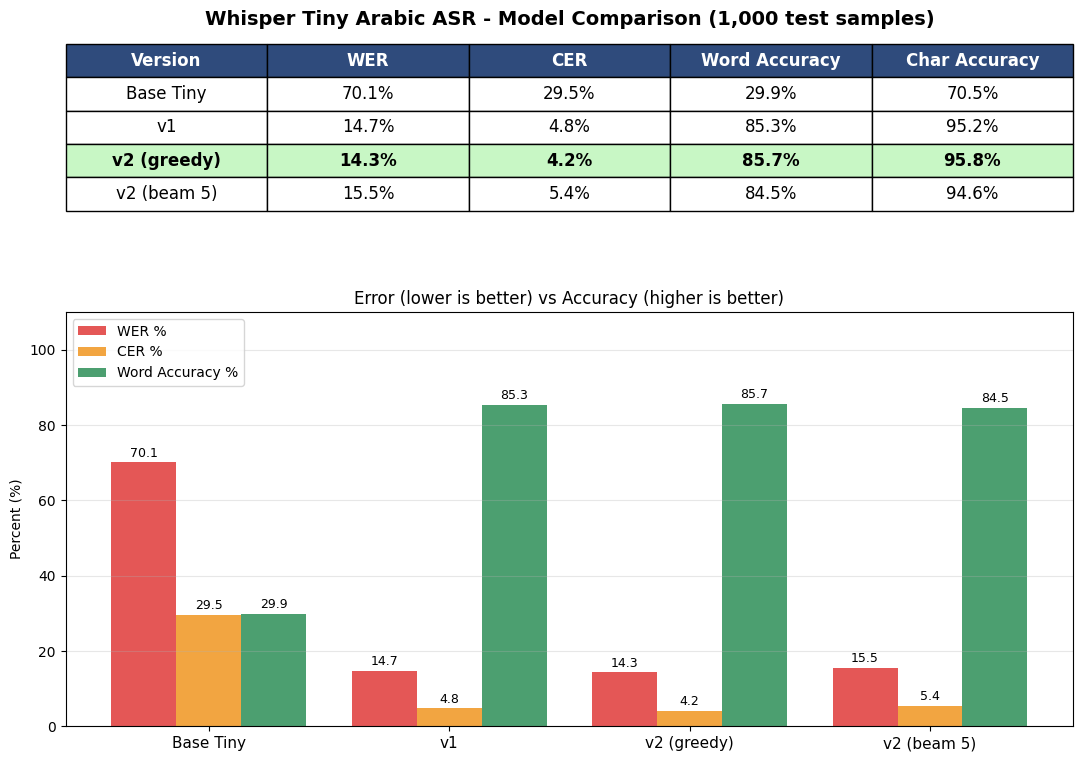

In [16]:
import matplotlib.pyplot as plt

versions = [
    ("Base Tiny", "before"),
    ("v1", "after"),
    ("v2 (greedy)", "after_v2"),
    ("v2 (beam 5)", "after_v2_beam5"),
]

rows = []
for label, name in versions:
    path = f"{WORK}/{name}/metrics.json"
    if os.path.exists(path):
        with open(path) as f:
            m = json.load(f)
        rows.append({
            "Version": label,
            "WER": m["wer"] * 100,
            "CER": m["cer"] * 100,
            "Word Acc": (1 - m["wer"]) * 100,
            "Char Acc": (1 - m["cer"]) * 100,
        })

result = pd.DataFrame(rows)
best_idx = result["WER"].idxmin()

fig = plt.figure(figsize=(13, 9))
grid = fig.add_gridspec(2, 1, height_ratios=[1, 2.2], hspace=0.3)

table_ax = fig.add_subplot(grid[0])
table_ax.axis("off")
cell_text = [
    [r["Version"], f"{r['WER']:.1f}%", f"{r['CER']:.1f}%", f"{r['Word Acc']:.1f}%", f"{r['Char Acc']:.1f}%"]
    for _, r in result.iterrows()
]
table = table_ax.table(
    cellText=cell_text,
    colLabels=["Version", "WER", "CER", "Word Accuracy", "Char Accuracy"],
    loc="center",
    cellLoc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 2)
for col in range(5):
    table[0, col].set_facecolor("#2f4b7c")
    table[0, col].set_text_props(color="white", weight="bold")
    table[best_idx + 1, col].set_facecolor("#c8f7c5")
    table[best_idx + 1, col].set_text_props(weight="bold")
table_ax.set_title("Whisper Tiny Arabic ASR - Model Comparison (1,000 test samples)", fontsize=14, weight="bold")

chart_ax = fig.add_subplot(grid[1])
x = range(len(result))
width = 0.27
series = [("WER", "WER %", "#e45756"), ("CER", "CER %", "#f2a541"), ("Word Acc", "Word Accuracy %", "#4c9f70")]
for offset, (col, label, color) in zip([-width, 0, width], series):
    bars = chart_ax.bar([i + offset for i in x], result[col], width, label=label, color=color)
    chart_ax.bar_label(bars, fmt="%.1f", fontsize=9, padding=2)

chart_ax.set_xticks(list(x))
chart_ax.set_xticklabels(result["Version"], fontsize=11)
chart_ax.set_ylabel("Percent (%)")
chart_ax.set_ylim(0, 110)
chart_ax.legend(loc="upper left")
chart_ax.grid(axis="y", alpha=0.3)
chart_ax.set_title("Error (lower is better) vs Accuracy (higher is better)", fontsize=12)

plt.show()